# Two steps Neural Networks

In [75]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions3D import getModel, kCrossVal, transfBestparam, import_data, normalization
from time import perf_counter
import pandas
import pickle
import os
from itertools import product
import keras
import tensorflow as tf


In [76]:
# reproducibility
seed=42
np.random.seed(seed)

keras.utils.set_random_seed(seed)

tf.random.set_seed(seed)

## Data preparation

In [77]:
file_path_D = os.path.join("..", "..", "Diffusion\DATA", "Discretizations.txt")
file_path_diff = os.path.join("..", "..", "Diffusion\DATA", "diffusion.txt")



Discretizations= np.loadtxt(
    file_path_D
).astype(
    int
)

diffusion= np.loadtxt(
    file_path_diff
).astype(
    int
)

In [78]:
########################     PREPARATION      ##########################
# introduction of the data
file_path_HF = os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_HF.mat")
(reaction_HF_test, U_HF_test, x_HF_test) = import_data(file_path_HF)
U_HF_test = U_HF_test[:, -1, :,44]


In [79]:
########################     NORMALIZATION  #########################
# Input

reaction_HF_test = normalization(reaction_HF_test)
x_HF_test = normalization(x_HF_test)
U_HF_test = normalization(U_HF_test)

In [80]:
#########################     TRAIN SET      ##########################
NepoLF = 200  # number of epochs for first NN: NN_LF
NepoHF = 200  # number of epochs for second NN: NN_HF

Nlf=40
n_HF=40

In [81]:
# TRANSFORMATION

permutation1 = np.random.permutation(len(reaction_HF_test))
permutation2 = np.random.permutation(len(x_HF_test))

reaction_HF = reaction_HF_test[permutation1][0:n_HF]
x_HF = x_HF_test[permutation2][0:n_HF]

grid1, grid2 = np.meshgrid(reaction_HF, x_HF)
reaction_HF = np.column_stack((grid1.ravel(), grid2.ravel()))
reaction_HF_test = np.array(list(product(reaction_HF_test.flatten(), x_HF_test.flatten())))

reaction_HF=np.c_[reaction_HF, np.abs(np.sin(5*np.pi*reaction_HF[:, 0])),np.abs(np.sin(3.5*np.pi*reaction_HF[:, 1])),np.ones(reaction_HF.shape[0])]
reaction_HF_test=np.c_[reaction_HF_test,np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0])) ,np.abs(np.sin(3.5*np.pi*reaction_HF_test[:, 1])),np.ones(reaction_HF_test.shape[0])]

##
p1, p2 = np.meshgrid(permutation1[0:n_HF], permutation2[0:n_HF])
permutation = np.column_stack((p1.ravel(), p2.ravel()))
U_HF = U_HF_test[permutation[:,0],permutation[:,1]] 
row, col = U_HF_test.shape
index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
U_HF_test = U_HF_test.flatten()[comb]
##

In [82]:
U_LF_list = []
U_HF_list = []

r2_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores LF MSE

(1600, 5)
(2300,)
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************


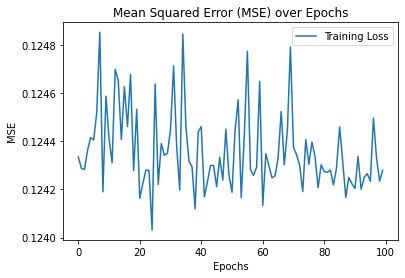

72/72 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.12486883616664558
R^2: -0.0012060283721178067
50/50 [==============================] - 0s 2ms/step


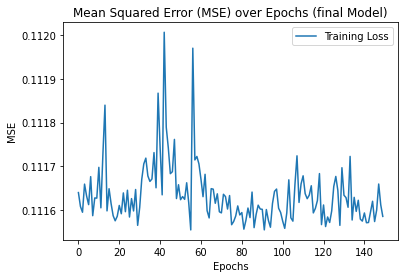

157/157 [==============================] - 0s 2ms/step
Elapsed time:  20.01772170001641

HF Model:
Test MSE: 0.11167381491662068
R^2: -6.887589504112057e-05
4/4 [==============================] - 0s 4ms/step


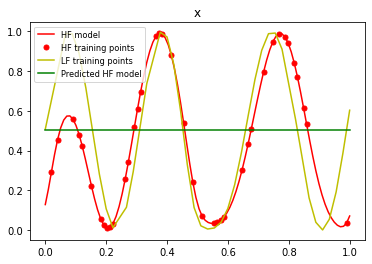

2/2 [==============================] - 0s 0s/step


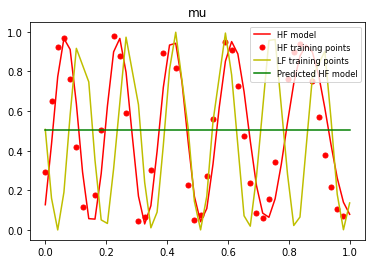

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_17248\3422321904.py:213: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_17248\3422321904.py:215: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_17248\3422321904.py:217: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_17248\3422321904.py:219: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

(1600, 5)
(2300,)
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************


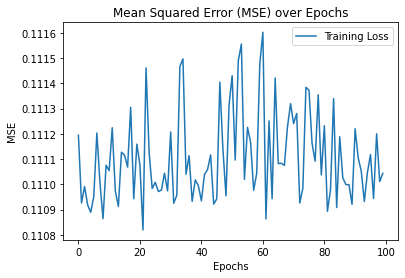

72/72 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.11072214735886206
R^2: -0.0019468066014194374
50/50 [==============================] - 0s 2ms/step


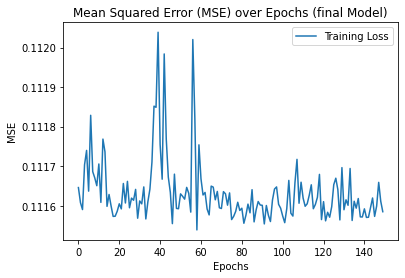

157/157 [==============================] - 0s 1ms/step
Elapsed time:  17.964559799991548

HF Model:
Test MSE: 0.11167381028889994
R^2: -6.883445256433696e-05
4/4 [==============================] - 0s 5ms/step


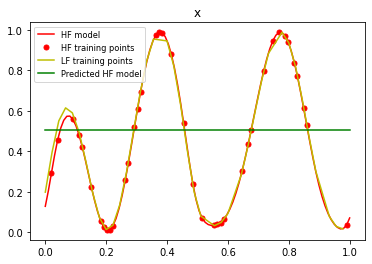

2/2 [==============================] - 0s 4ms/step


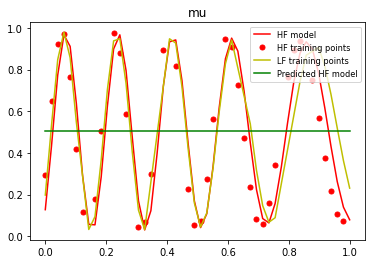

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_17248\3422321904.py:213: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_17248\3422321904.py:215: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_17248\3422321904.py:217: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_17248\3422321904.py:219: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

(1600, 5)
(2300,)
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************


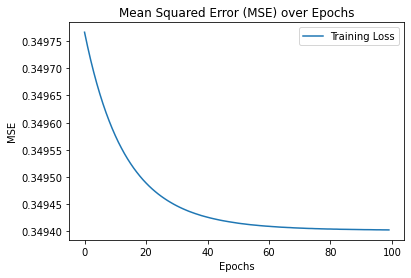

72/72 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.35583200620871275
R^2: -2.2338226456825163
50/50 [==============================] - 0s 2ms/step


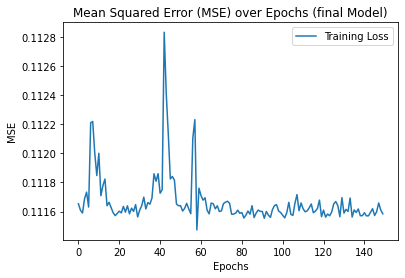

157/157 [==============================] - 0s 2ms/step
Elapsed time:  17.873459300026298

HF Model:
Test MSE: 0.11167356538654558
R^2: -6.664128649025436e-05
4/4 [==============================] - 0s 2ms/step


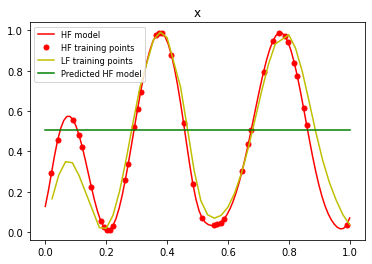

2/2 [==============================] - 0s 0s/step


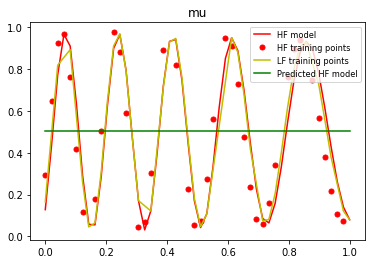

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_17248\3422321904.py:213: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_17248\3422321904.py:215: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_17248\3422321904.py:217: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_17248\3422321904.py:219: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

(1600, 5)
(2300,)
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************


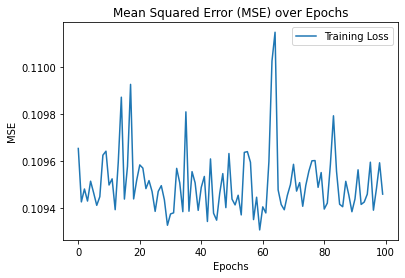

72/72 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.10951622406286673
R^2: -0.001876967067553137
50/50 [==============================] - 0s 2ms/step


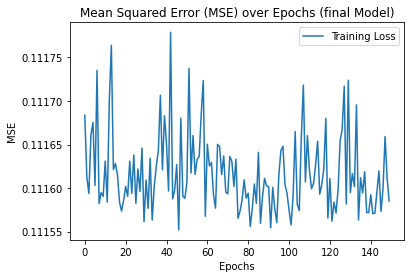

157/157 [==============================] - 0s 2ms/step
Elapsed time:  17.50278540002182

HF Model:
Test MSE: 0.11167382186081297
R^2: -6.893808213992436e-05
4/4 [==============================] - 0s 2ms/step


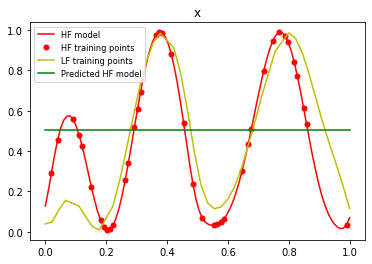

2/2 [==============================] - 0s 0s/step


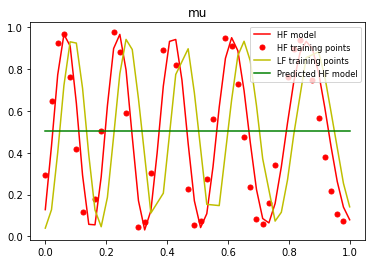

   Discretization  diffusion       R2
0            46.0        0.0 -0.00007
1            46.0        5.0 -0.00007
2            46.0       75.0 -0.00007
3            46.0        1.0 -0.00007
   Discretization  diffusion      MSE
0            46.0        0.0  0.11167
1            46.0        5.0  0.11167
2            46.0       75.0  0.11167
3            46.0        1.0  0.11167


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_17248\3422321904.py:213: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_17248\3422321904.py:215: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_17248\3422321904.py:217: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_17248\3422321904.py:219: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

In [83]:

test_mse_HF_list = []
test_mse_LF_list = []

r2_HF_list = []
r2_LF_list = []
Discretizations=np.array([46])
for m in range(len(Discretizations)):
    for d in range(len(diffusion)):
        file_name= os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat")
        #file_name="Diffusion\DATA\reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
        (reaction_LF_test, U_LF_test, x_LF_test) = import_data(file_name)
#file_path_LF = "..\..\Diffusion\DATA\reaction_diffusion_LF_46_d75.mat"
       
        U_LF_test = U_LF_test[
        :,
        - 1,
        :,
        int(4*(Discretizations[m]-1)/9)
        ]
         
        reaction_LF_test = normalization(reaction_LF_test)
        x_LF_test = normalization(x_LF_test)
        U_LF_test = normalization(U_LF_test)

        
        L=np.minimum(Nlf,x_LF_test.shape[0])
        permutation1 = np.random.permutation(len(reaction_LF_test))
        permutation2 = np.random.permutation(len(x_LF_test))
        reaction_LF = reaction_LF_test[permutation1][0:Nlf]    # problema di consistenza qui: non stai confrontando stesso numero di dati, ma è cosairreparabile se non creando nuovo dataset
        x_LF = x_LF_test[permutation2][0:L]
        
        grid1, grid2 = np.meshgrid(reaction_LF, x_LF)
        reaction_LF = np.column_stack((grid1.ravel(), grid2.ravel()))
        reaction_LF_test = np.array(list(product(reaction_LF_test.flatten(), x_LF_test.flatten())))
       
        
        reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0])),np.abs(np.sin(3.5*np.pi*reaction_LF[:, 1])),np.ones(reaction_LF.shape[0])]
        reaction_LF_test=np.c_[reaction_LF_test,np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0])) ,np.abs(np.sin(3.5*np.pi*reaction_LF_test[:, 1])),np.ones(reaction_LF_test.shape[0])]

      
        p1, p2 = np.meshgrid(permutation1[0:Nlf], permutation2[0:L])
        permutation = np.column_stack((p1.ravel(), p2.ravel()))
        U_train_LF = U_LF_test[permutation[:,0],permutation[:,1]]
        
        ##
        row, col = U_LF_test.shape
        index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
        comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
        U_LF_test = U_LF_test.flatten()[comb]
        ##      
        print(reaction_LF.shape)
        print(U_LF_test.shape)

        print(
        f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
        )
        
        print(
        f"********************  # Diff: = {diffusion[d]}  ********************"
        )
        
        ##########################       FIRST NN: NN_LF     ##########################
        K.clear_session()
        bestLF_params = {
            "lr": 0.0255,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
        } 

        
        modelLF = getModel(bestLF_params, "LF")  # ann_functions
        histLF = modelLF.fit(
            reaction_LF, U_train_LF, epochs=NepoLF, batch_size=Nlf, verbose=0
        )
        plt.plot(modelLF.history.history['loss'][100:], label='Training Loss')
        plt.title('Mean Squared Error (MSE) over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        plt.show()

        ULF = modelLF.predict(reaction_LF_test)

        U_LF_list.append(ULF)
        print("\nLF Model:")
        
        test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
        test_mse_LF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
            np.square(U_LF_test - np.mean(U_LF_test))
        )
        r2_LF_list.append(r_2)
        print(f"R^2: {r_2}")
        
        start = perf_counter()
        reaction_test_help = modelLF.predict(reaction_HF_test)[:, 0]
        reaction_test_in = np.concatenate(
        (reaction_HF_test, reaction_test_help.reshape(-1,1)),axis=1
        )   # <- TEST INPUT for the second NN: NN_HF

        reaction_train_help = modelLF.predict(reaction_HF)[
            :, 0
        ]  # f_LF(mu_hf_train)
        reaction_final = np.concatenate(
        (reaction_HF, reaction_train_help.reshape(-1,1)),axis=1
        )  # <- TRAINING INPUT for the second NN: NN_HF

        name = "2step"
        K.clear_session()
        # best parameters obtained by HPO:

        best_params = {
            "kernel_init": "uniform",
            "l2weight": 0.0002588943618918075,
            "lr": 0.008365144388542751,
            "nodes": 64.0,
            "opt": "Adam",
        }
        
        
        finalModel = getModel(
            best_params, name
        )  # final model chosen according to the best paramters
        hist = finalModel.fit(
            reaction_final,
            U_HF,
            validation_data=(reaction_test_in, U_HF_test),
            epochs=NepoHF,
            batch_size=n_HF,
            verbose=0,
            validation_freq=20,
        )

        plt.plot(finalModel.history.history['loss'][50:], label='Training Loss')
        plt.title('Mean Squared Error (MSE) over Epochs (final Model)')
        plt.xlabel('Epochs')
        plt.ylabel('MSE')
        plt.legend()
        plt.show()
        
        UHF = finalModel.predict(reaction_test_in)
        U_HF_list.append(UHF)

        stop = perf_counter()
        elapsed = stop - start
        print("Elapsed time: ", elapsed)
        print("\nHF Model:")

        test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
        test_mse_HF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_HF_list.append(r2_HF)
        print(f"R^2: {r2_HF}")
        
        
        index_order=np.argsort(reaction_test_in[:,0])
        index_order_LF=np.argsort(reaction_LF[:,0])
        
        plt.figure()
        mask1_test=np.where(reaction_test_in[:,0]==reaction_test_in[:,0][index_order[2]])
        mask1=np.where(reaction_final[:,0]==np.min(reaction_final[:,0]))
        mask1_LF=np.where(reaction_LF[:,0]==reaction_LF[:,0][index_order_LF[2]])
        order=np.argsort(reaction_LF[mask1_LF,1])
# plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
        plt.plot(reaction_test_in[mask1_test,1].T, U_HF_test[mask1_test], "r-", linewidth=1.5, label="HF model")
        plt.plot(reaction_final[mask1,1].T, U_HF[mask1], "ro", markersize=5, label="HF training points")
        plt.plot(reaction_LF[mask1_LF,1].T[order[0,:]], U_train_LF[mask1_LF][order[0,:]], "y-", markersize=5, label="LF training points")
        plt.plot(
        reaction_test_in[mask1_test, 1].T,
        finalModel.predict(reaction_test_in[mask1_test, :][0,:,:]),
        "g-",
        markersize=5,
        label="Predicted HF model",
        )

        plt.legend(prop={"size": 8.3})  
        plt.title("x")
        plt.show()
        
        index_order=np.argsort(reaction_test_in[:,1])
        index_order_LF=np.argsort(reaction_LF[:,1])  

        plt.figure()
        mask2_test=np.where(reaction_test_in[:,1]==reaction_test_in[:,1][index_order[2]])
        mask2=np.where(reaction_final[:,1]==np.min(reaction_final[:,1]))   
        mask2_LF=np.where(reaction_LF[:,1]==reaction_LF[:,1][index_order_LF[2]])
        order=np.argsort(reaction_LF[mask2_LF,0])
# plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
        plt.plot(reaction_test_in[mask2_test,0].T, U_HF_test[mask2_test], "r-", linewidth=1.5, label="HF model")
        plt.plot(reaction_final[mask2,0].T, U_HF[mask2], "ro", markersize=5, label="HF training points")
        plt.plot(reaction_LF[mask2_LF,0].T[order[0,:]], U_train_LF[mask2_LF][order[0,:]], "y-", markersize=5, label="LF training points")
        plt.plot(
        reaction_test_in[mask2_test, 0].T,
        finalModel.predict(reaction_test_in[mask2_test, :][0,:,:]),
        "g-",
        markersize=5,
        label="Predicted HF model",
        )

        plt.legend(prop={"size": 8.3})
        plt.title("mu")
        plt.show()

        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
        r2_LF_df=r2_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
        r2_HF_df=r2_HF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
        mse_LF_df=mse_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
        mse_HF_df=mse_HF_df.append(new, ignore_index=True)
        
        if not r2_HF_list[:-1]:
            save_model(modelLF,"modelLF2NN.h5")
            save_model(finalModel,"finalModel2NN.h5")
        elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
            save_model(modelLF,"modelLF2NN.h5")
            save_model(finalModel,"finalModel2NN.h5")
        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))



## Save the output

In [84]:
os.makedirs("MF_LF_30_5000_HF_15_3000_2NN_multiparam")

r2_HF_df.to_csv(
    "./MF_LF_30_5000_HF_15_3000_2NN_multiparam/r2_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_HF_df.to_csv(
    "./MF_LF_30_5000_HF_15_3000_2NN_multiparam/mse_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
r2_LF_df.to_csv(
    "./MF_LF_30_5000_HF_15_3000_2NN_multiparam/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_LF_df.to_csv(
    "./MF_LF_30_5000_HF_15_3000_2NN_multiparam/mse_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)

with open("./MF_LF_30_5000_HF_15_3000_2NN_multiparam/U_HF_list.data", "wb") as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open("./MF_LF_30_5000_HF_15_3000_2NN_multiparam/U_LF_list.data", "wb") as filehandle:
    pickle.dump(U_LF_list, filehandle)

FileExistsError: [WinError 183] Impossibile creare un file, se il file esiste già: 'MF_LF_30_5000_HF_15_3000_2NN_multiparam'